Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Libraries imported successfully
✅ Data loaded: (4707, 19)
Columns: ['TRANSFORMER_CODE', 'TRANSFORMER_LAT', 'TRANSFORMER_LON', 'ACCOUNT_NO', 'CUSTOMER_LAT', 'CUSTOMER_LON', 'MONTH', 'YEAR', 'IMPORT_kWh', 'EXPORT_kWh', 'NET_CONSUMPTION_kWh', 'HAS_SOLAR', 'INV_CAPACITY', 'CAL_TARIFF', 'PHASE', 'DATA_QUALITY', 'DISTANCE_FROM_TF_M', 'SOURCE', 'CONSUMPTION_LEVEL']
Unique households: 389

🔤 SORTING DATA (CRITICAL FOR TIME SERIES)
✅ Data sorted by household and time
   Date range: 2025-2025, Months: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12)]

⏰ CREATING TEMPORAL FEATURES
✅ Temporal features created
   New features: month_sin, month_cos, quarter, is_dry_season, is_holiday_month, etc.


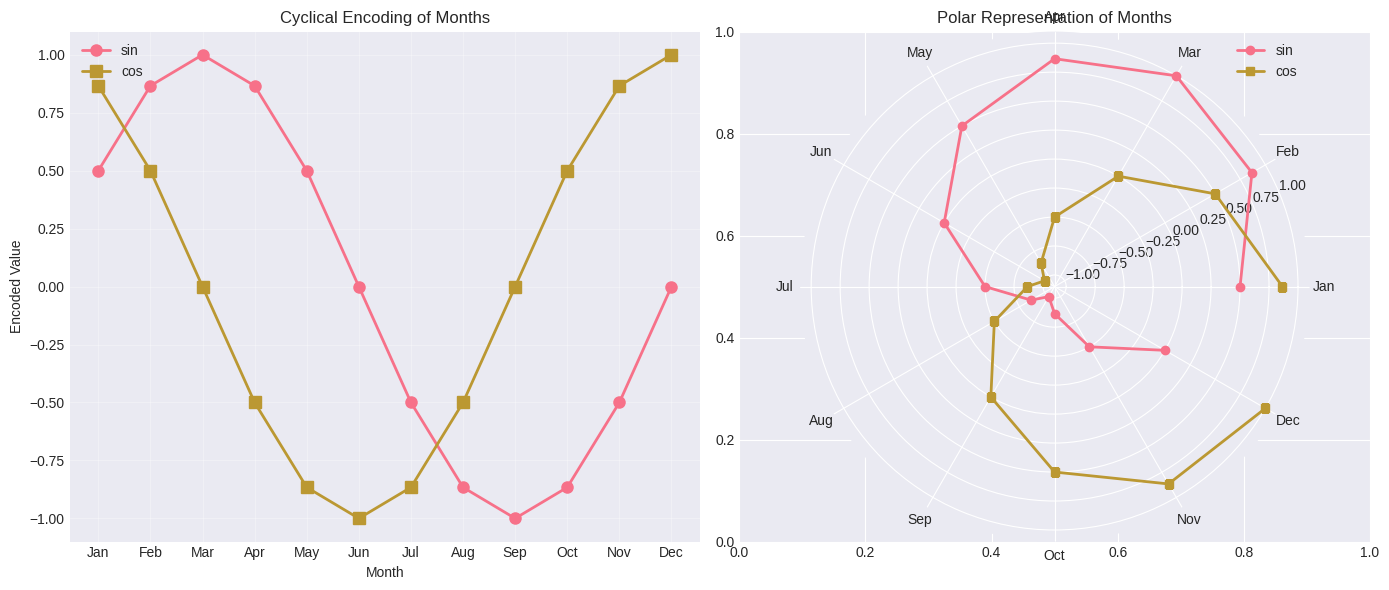


⏱️ CREATING LAG FEATURES
✅ Created lag features: [1, 2, 3, 6, 12]

📊 Lag correlations with target:
   Lag  Correlation
0    1     0.730736
1    2     0.833506
2    3     0.663098
3    6     0.826652
4   12     0.576966


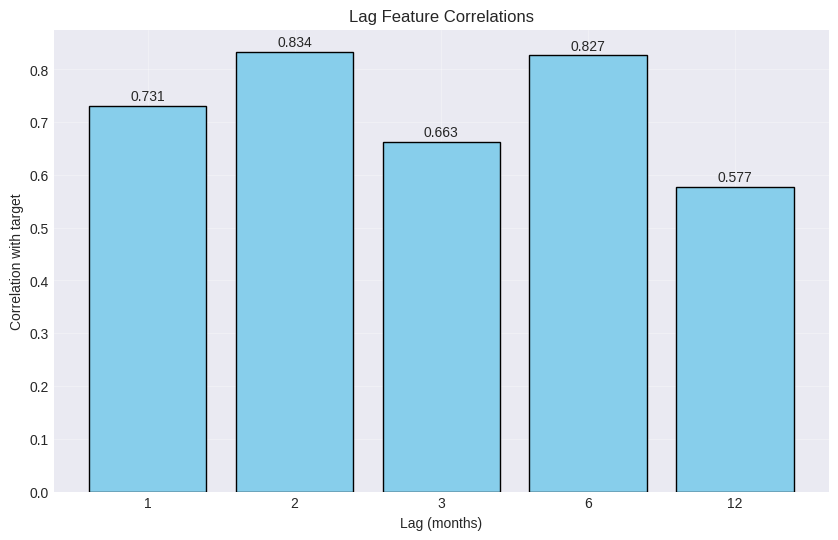


📊 CREATING ROLLING STATISTICS
✅ Created rolling statistics for windows: [3, 6, 12]

📈 CREATING DIFFERENCED FEATURES
✅ Created differenced features

📐 CREATING RATIO FEATURES
✅ Created ratio features

🏷️ ENCODING CATEGORICAL FEATURES
✅ Categorical features encoded
   New columns: ['tariff_D1', 'tariff_GP11', 'tariff_GP12'] + ['phase_TP', 'phase_SP']

📍 CREATING GEOGRAPHIC FEATURES
✅ Created geographic features

📋 COMPILING ALL FEATURES
✅ Total features: 50

📊 Feature categories:
   Temporal features: 11
   Lag features: 5
   Rolling statistics: 12
   Differenced features: 4
   Ratio features: 4
   Static features: 3
   Categorical encoded: 11

🧹 HANDLING MISSING VALUES
NaN before filling: 25486

📊 Feature types:
   Numeric features: 49
   Categorical features: 1

🔢 Handling numeric features...
   Processing lag_1: 389 NaNs
   Processing lag_2: 778 NaNs
   Processing lag_3: 1167 NaNs
   Processing lag_6: 2334 NaNs
   Processing lag_12: 4346 NaNs
   Processing rolling_mean_3: 389 NaNs
  

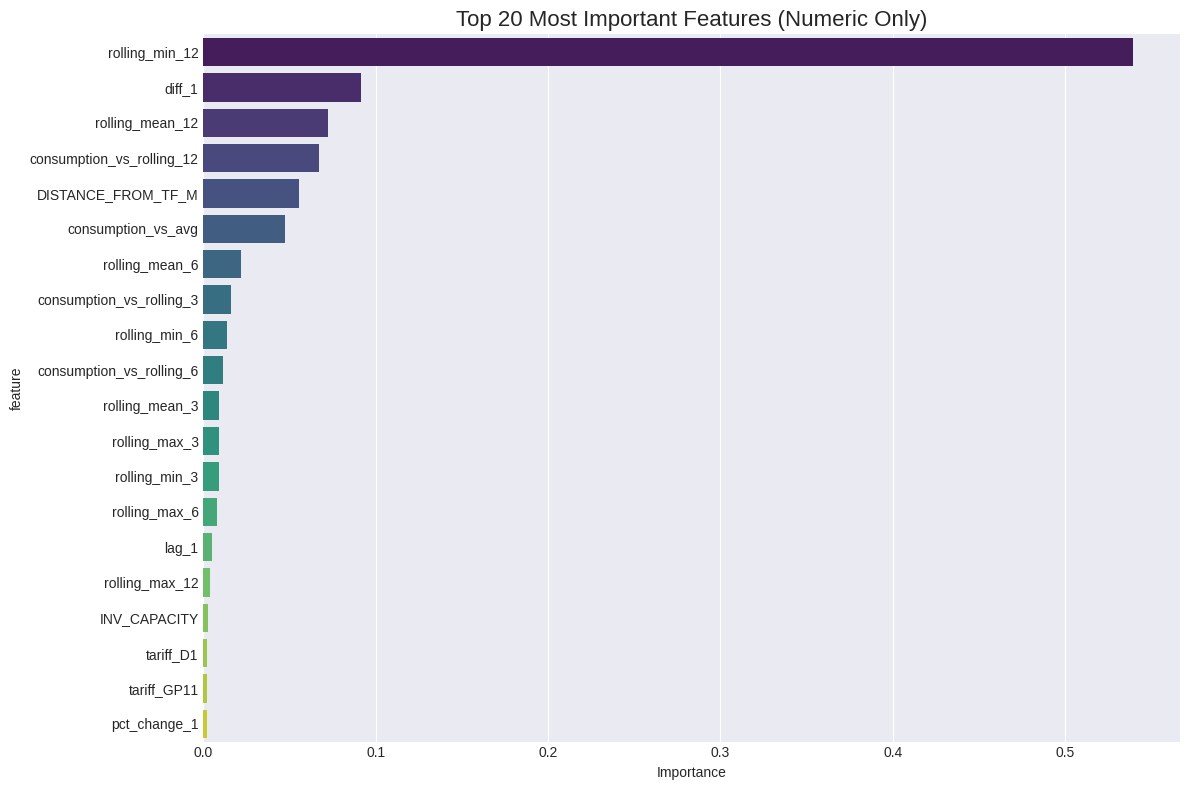


📊 Categorical Feature Analysis:
   Categorical features: ['distance_bin']
   distance_bin: max absolute correlation = 0.0695

📊 Mutual Information Scores (Numeric Features):

Top 15 mutual information scores:
                  feature  mi_score
           rolling_min_12  0.848748
            rolling_min_6  0.815807
          rolling_mean_12  0.716024
            rolling_min_3  0.713724
           rolling_mean_6  0.702127
                    lag_1  0.658053
                    lag_2  0.638830
           rolling_mean_3  0.622256
            rolling_max_3  0.620291
            rolling_max_6  0.594476
           rolling_max_12  0.592493
                    lag_6  0.438819
                    lag_3  0.359384
       consumption_vs_avg  0.298720
consumption_vs_rolling_12  0.297251

🔗 Top 15 correlations with target (numeric only):
                  feature  correlation
           rolling_min_12     0.669902
            rolling_min_6     0.667164
          rolling_mean_12     0.654172
       

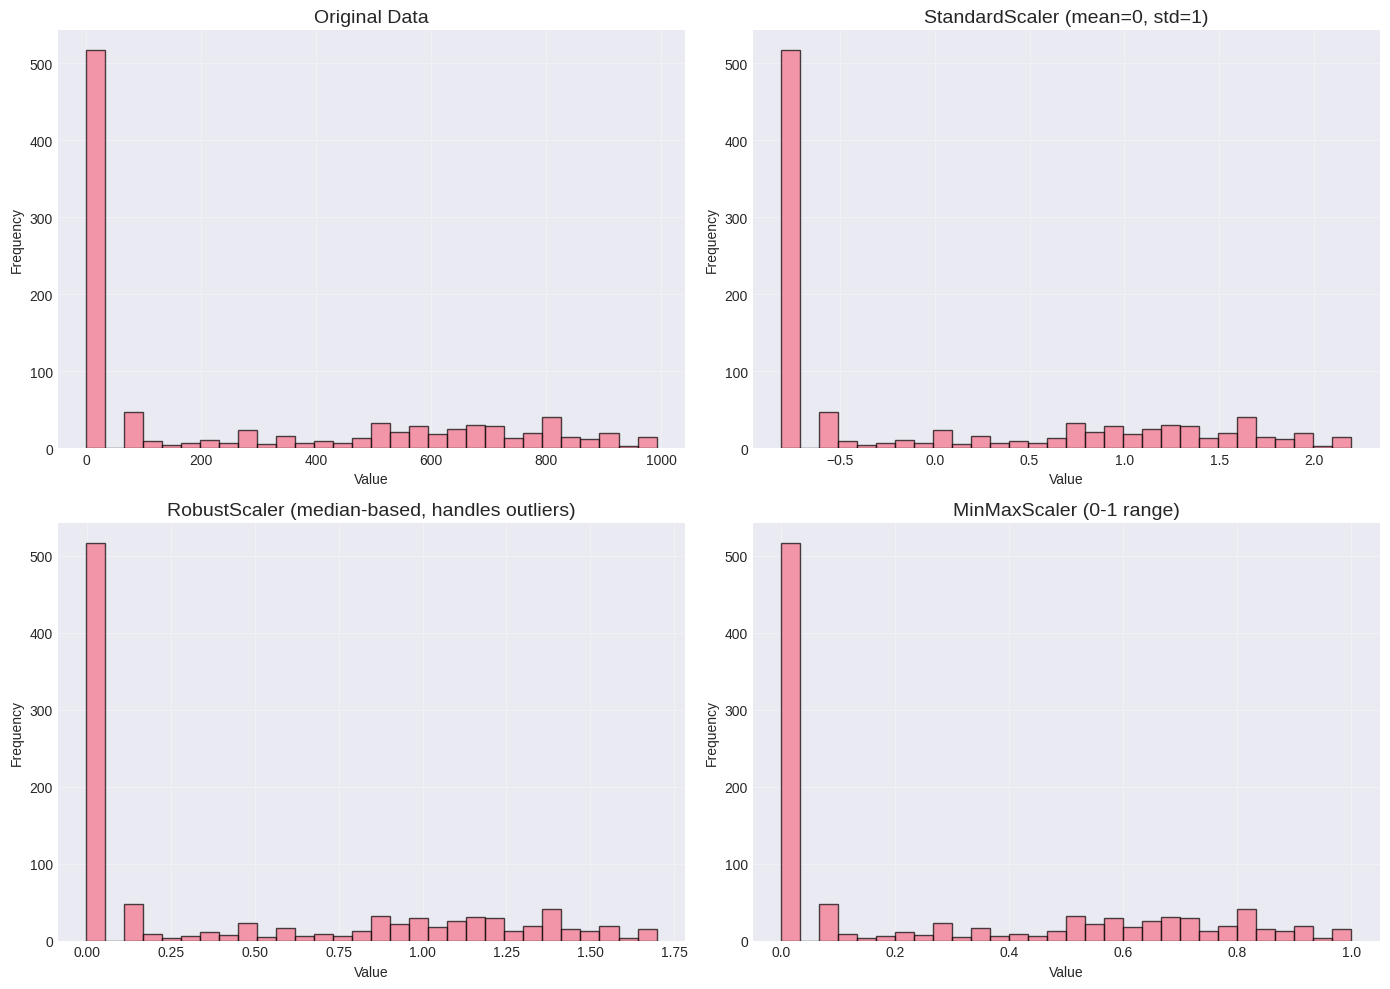


📋 SCALING RECOMMENDATION:
   Based on outlier analysis from EDA, use RobustScaler
   Reason: Handles the wide range of consumption values better than StandardScaler

✅ CREATING FINAL FEATURE SET
✅ Final feature set: 30 features

Features by category:
   Temporal: 1
   Lag: 5
   Rolling: 15
   Diff: 4
   Ratio: 4
   Static: 2
   Categorical: 1

🔍 Final NaN check:
   X_final NaNs: 0
   y_final NaNs: 0

💾 SAVING PREPROCESSED DATA
✅ Saved files:
   - feature_config.json (complete feature configuration)
   - X_sample.csv (sample features for testing)
   - y_sample.csv (sample targets for testing)

📋 FEATURE ENGINEERING SUMMARY

FEATURE ENGINEERING COMPLETE
────────────────────────────────────────────
Original features: 19
Engineered features created: 30
Final feature set: 30

FEATURE CATEGORIES:
• Temporal features: 1 (cyclical encoding, seasons, holidays)
• Lag features: 5 (1,2,3,6,12 months)
• Rolling statistics: 15 (means, stds, min, max)
• Differenced features: 4 (changes, percentages)

In [ ]:
"""
# 02 - Feature Engineering
## Creating comprehensive features for consumption forecasting

**Purpose**: Engineer and select optimal features for LSTM model
"""

# 1. SETUP AND IMPORTS
from google.colab import drive
drive.mount('/content/drive')

# Install additional libraries if needed
!pip install tsfresh scikit-learn pandas numpy matplotlib seaborn -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, mutual_info_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from scipy import stats
import warnings
import json
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print("Libraries imported successfully")


# 2. LOAD CLEANED DATA
# Load data from previous notebook
DATA_PATH = "/content/drive/MyDrive/DSGP_Group16_25 26/processed_new/MASTER_DATASET_RESIDENTIAL_ONLY.csv"
df = pd.read_csv(DATA_PATH)

print(f"Data loaded: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"Unique households: {df['ACCOUNT_NO'].nunique()}")


# 3. SORT BY HOUSEHOLD AND TIME

print("\n" + "="*60)
print("SORTING DATA")
print("="*60)

df = df.sort_values(['ACCOUNT_NO', 'YEAR', 'MONTH']).reset_index(drop=True)
print("Data sorted by household and time")
print(f"   Date range: {df['YEAR'].min()}-{df['YEAR'].max()}, Months: {sorted(df['MONTH'].unique())}")


# 4. TEMPORAL FEATURES
print("\n" + "="*60)
print("CREATING TEMPORAL FEATURES")
print("="*60)

df_feat = df.copy()

# 4.1 Cyclical encoding of month
df_feat['month_sin'] = np.sin(2 * np.pi * df_feat['MONTH'] / 12)
df_feat['month_cos'] = np.cos(2 * np.pi * df_feat['MONTH'] / 12)

# 4.2 Quarter features
df_feat['quarter'] = ((df_feat['MONTH'] - 1) // 3) + 1
df_feat['quarter_sin'] = np.sin(2 * np.pi * df_feat['quarter'] / 4)
df_feat['quarter_cos'] = np.cos(2 * np.pi * df_feat['quarter'] / 4)

# 4.3 Season flags (Sri Lanka specific)
# Following Sri Lanka's climate patterns
df_feat['is_dry_season'] = df_feat['MONTH'].isin([2, 3, 4, 7, 8]).astype(int)
df_feat['is_wet_season'] = df_feat['MONTH'].isin([5, 6, 9, 10, 11]).astype(int)
df_feat['is_intermediate'] = df_feat['MONTH'].isin([1, 12]).astype(int)

# 4.4 Holiday flags (Sri Lanka specific)
holiday_months = [1, 4, 5, 12]  # Thai Pongal, Avurudu, Vesak, Christmas
df_feat['is_holiday_month'] = df_feat['MONTH'].isin(holiday_months).astype(int)

# 4.5 Pre/post holiday (capture holiday preparation effects)
df_feat['is_pre_holiday'] = df_feat['MONTH'].isin([3, 11]).astype(int)  # Month before holiday
df_feat['is_post_holiday'] = df_feat['MONTH'].isin([2, 6]).astype(int)  # Month after holiday

print("Temporal features created")
print(f"   New features: month_sin, month_cos, quarter, is_dry_season, is_holiday_month, etc.")

# Visualize cyclical encoding
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot sin/cos encoding
months = np.arange(1, 13)
month_sin = np.sin(2 * np.pi * months / 12)
month_cos = np.cos(2 * np.pi * months / 12)

axes[0].plot(months, month_sin, 'o-', label='sin', linewidth=2, markersize=8)
axes[0].plot(months, month_cos, 's-', label='cos', linewidth=2, markersize=8)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Encoded Value')
axes[0].set_title('Cyclical Encoding of Months')
axes[0].set_xticks(months)
axes[0].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Polar plot
ax = plt.subplot(1, 2, 2, projection='polar')
angles = 2 * np.pi * (months - 1) / 12
ax.plot(angles, month_sin, 'o-', label='sin', linewidth=2)
ax.plot(angles, month_cos, 's-', label='cos', linewidth=2)
ax.set_title('Polar Representation of Months')
ax.set_xticks(angles)
ax.set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                    'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()


# 5. LAG FEATURES

print("\n" + "="*60)
print("⏱CREATING LAG FEATURES")
print("="*60)

lags = [1, 2, 3, 6, 12]

for lag in lags:
    df_feat[f'lag_{lag}'] = df_feat.groupby('ACCOUNT_NO')['NET_CONSUMPTION_kWh'].shift(lag)

print(f"Created lag features: {lags}")

# Check correlation of lags with target
corr_data = []
valid_lags = []
for lag in lags:
    col = f'lag_{lag}'
    if col in df_feat.columns:
        corr = df_feat[col].corr(df_feat['NET_CONSUMPTION_kWh'])
        if not pd.isna(corr):
            corr_data.append({'Lag': lag, 'Correlation': corr})
            valid_lags.append(lag)

corr_df = pd.DataFrame(corr_data)
print("\nLag correlations with target:")
print(corr_df)

# Plot lag correlations
plt.figure(figsize=(10, 6))
bars = plt.bar(corr_df['Lag'].astype(str), corr_df['Correlation'], color='skyblue', edgecolor='black')
plt.xlabel('Lag (months)')
plt.ylabel('Correlation with target')
plt.title('Lag Feature Correlations')
plt.grid(True, alpha=0.3)

# Add value labels
for bar, val in zip(bars, corr_df['Correlation']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', fontsize=10)

plt.show()


# 6. ROLLING STATISTICS (CAPTURE TRENDS AND VOLATILITY)
print("\n" + "="*60)
print("CREATING ROLLING STATISTICS")
print("="*60)

windows = [3, 6, 12]

for window in windows:
    # Rolling mean (trend)
    df_feat[f'rolling_mean_{window}'] = df_feat.groupby('ACCOUNT_NO')['NET_CONSUMPTION_kWh'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).mean()
    )

    # Rolling std (volatility)
    df_feat[f'rolling_std_{window}'] = df_feat.groupby('ACCOUNT_NO')['NET_CONSUMPTION_kWh'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).std()
    )

    # Rolling min (baseline)
    df_feat[f'rolling_min_{window}'] = df_feat.groupby('ACCOUNT_NO')['NET_CONSUMPTION_kWh'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).min()
    )

    # Rolling max (peak)
    df_feat[f'rolling_max_{window}'] = df_feat.groupby('ACCOUNT_NO')['NET_CONSUMPTION_kWh'].transform(
        lambda x: x.shift(1).rolling(window, min_periods=1).max()
    )

print(f"Created rolling statistics for windows: {windows}")


# 7. DIFFERENCING (for stationarity)
print("\n" + "="*60)
print("CREATING DIFFERENCED FEATURES")
print("="*60)

# First difference (month-over-month change)
df_feat['diff_1'] = df_feat.groupby('ACCOUNT_NO')['NET_CONSUMPTION_kWh'].diff(1)

# Seasonal difference (12 months - year-over-year change)
df_feat['diff_12'] = df_feat.groupby('ACCOUNT_NO')['NET_CONSUMPTION_kWh'].diff(12)

# Percentage change (relative changes)
df_feat['pct_change_1'] = df_feat.groupby('ACCOUNT_NO')['NET_CONSUMPTION_kWh'].pct_change(1) * 100
df_feat['pct_change_12'] = df_feat.groupby('ACCOUNT_NO')['NET_CONSUMPTION_kWh'].pct_change(12) * 100

print("Created differenced features")

# Check stationarity with ADF test for a sample household
sample_account = df_feat['ACCOUNT_NO'].iloc[0]
sample_series = df_feat[df_feat['ACCOUNT_NO'] == sample_account]['NET_CONSUMPTION_kWh'].dropna()

from statsmodels.tsa.stattools import adfuller

if len(sample_series) > 12:
    adf_result = adfuller(sample_series)
    print(f"\nADF Test for stationarity (sample household):")
    print(f"   ADF Statistic: {adf_result[0]:.4f}")
    print(f"   p-value: {adf_result[1]:.4f}")
    if adf_result[1] < 0.05:
        print("   Series is stationary")
    else:
        print("   Series is non-stationary - differencing may help")


# 8. RATIO FEATURES
print("\n" + "="*60)
print("CREATING RATIO FEATURES")
print("="*60)

# Consumption relative to household average
df_feat['consumption_vs_avg'] = df_feat.groupby('ACCOUNT_NO')['NET_CONSUMPTION_kWh'].transform(
    lambda x: x / x.expanding().mean()
)

# Consumption relative to rolling average
for window in [3, 6, 12]:
    df_feat[f'consumption_vs_rolling_{window}'] = (
        df_feat['NET_CONSUMPTION_kWh'] / df_feat[f'rolling_mean_{window}']
    )

print("Created ratio features")


# 9. ENCODE CATEGORICAL FEATURES
print("\n" + "="*60)
print("ENCODING CATEGORICAL FEATURES")
print("="*60)

# One-hot encode tariff
tariff_dummies = pd.get_dummies(df_feat['CAL_TARIFF'], prefix='tariff')
df_feat = pd.concat([df_feat, tariff_dummies], axis=1)

# Encode phase
df_feat['phase_TP'] = (df_feat['PHASE'] == 'TP').astype(int)
df_feat['phase_SP'] = (df_feat['PHASE'] == 'SP').astype(int)

# Encode solar
df_feat['has_solar'] = df_feat['HAS_SOLAR'].astype(int)

# Encode data quality
if 'DATA_QUALITY' in df_feat.columns:
    quality_dummies = pd.get_dummies(df_feat['DATA_QUALITY'], prefix='quality')
    df_feat = pd.concat([df_feat, quality_dummies], axis=1)

print(f"Categorical features encoded")
print(f"   New columns: {list(tariff_dummies.columns)} + ['phase_TP', 'phase_SP']")


# 10. GEOGRAPHIC FEATURES
print("\n" + "="*60)
print("CREATING GEOGRAPHIC FEATURES")
print("="*60)

# Distance to transformer (already exists, but we can create bins)
df_feat['distance_bin'] = pd.cut(df_feat['DISTANCE_FROM_TF_M'],
                                  bins=[0, 100, 200, 300, 400, 500],
                                  labels=['0-100m', '100-200m', '200-300m', '300-400m', '400-500m'])

# One-hot encode distance bins
distance_dummies = pd.get_dummies(df_feat['distance_bin'], prefix='distance')
df_feat = pd.concat([df_feat, distance_dummies], axis=1)

print("Created geographic features")


# 11. COMPILE ALL FEATURES

print("\n" + "="*60)
print("COMPILING ALL FEATURES")
print("="*60)

# Define all feature categories
temporal_features = ['month_sin', 'month_cos', 'quarter', 'quarter_sin', 'quarter_cos',
                     'is_dry_season', 'is_wet_season', 'is_intermediate',
                     'is_holiday_month', 'is_pre_holiday', 'is_post_holiday']

lag_features = [f'lag_{lag}' for lag in lags if f'lag_{lag}' in df_feat.columns]

rolling_features = []
for window in windows:
    for stat in ['mean', 'std', 'min', 'max']:
        col = f'rolling_{stat}_{window}'
        if col in df_feat.columns:
            rolling_features.append(col)

diff_features = ['diff_1', 'diff_12', 'pct_change_1', 'pct_change_12']
diff_features = [f for f in diff_features if f in df_feat.columns]

ratio_features = ['consumption_vs_avg'] + [f'consumption_vs_rolling_{w}' for w in windows]
ratio_features = [f for f in ratio_features if f in df_feat.columns]

static_features = ['has_solar', 'INV_CAPACITY', 'DISTANCE_FROM_TF_M']

categorical_features = list(tariff_dummies.columns) + ['phase_TP', 'phase_SP']
if 'distance_bin' in df_feat.columns:
    categorical_features.extend([col for col in df_feat.columns if col.startswith('distance_')])

# Combine all features
all_features = (temporal_features + lag_features + rolling_features +
                diff_features + ratio_features + static_features + categorical_features)

# Ensure all features exist
final_features = [f for f in all_features if f in df_feat.columns]
print(f"Total features: {len(final_features)}")

print("\nFeature categories:")
print(f"   Temporal features: {len(temporal_features)}")
print(f"   Lag features: {len(lag_features)}")
print(f"   Rolling statistics: {len(rolling_features)}")
print(f"   Differenced features: {len(diff_features)}")
print(f"   Ratio features: {len(ratio_features)}")
print(f"   Static features: {len(static_features)}")
print(f"   Categorical encoded: {len(categorical_features)}")


# 12. HANDLE MISSING VALUES
print("\n" + "="*60)
print("HANDLING MISSING VALUES")
print("="*60)

# Check NaNs before filling
nan_before = df_feat[final_features].isna().sum().sum()
print(f"NaN before filling: {nan_before}")

# SEPARATE NUMERIC AND CATEGORICAL COLUMNS
numeric_features = []
categorical_features_clean = []

for col in final_features:
    if pd.api.types.is_numeric_dtype(df_feat[col]):
        numeric_features.append(col)
    else:
        categorical_features_clean.append(col)

print(f"\nFeature types:")
print(f"   Numeric features: {len(numeric_features)}")
print(f"   Categorical features: {len(categorical_features_clean)}")

# Handle numeric features with a more robust approach
print("\nHandling numeric features...")

for col in numeric_features:
    # Count NaNs in this column
    nan_count = df_feat[col].isna().sum()
    if nan_count > 0:
        print(f"   Processing {col}: {nan_count} NaNs")

        if any(x in col for x in ['lag_', 'rolling_', 'diff_', 'pct_']):
            # For time-based features, try filling per household
            try:
                df_feat[col] = df_feat.groupby('ACCOUNT_NO')[col].transform(
                    lambda x: x.fillna(x.expanding().mean())
                )
            except:
                # If that fails, fill with overall median
                df_feat[col] = df_feat[col].fillna(df_feat[col].median())
        else:
            # For other numeric features, fill with median
            df_feat[col] = df_feat[col].fillna(df_feat[col].median())

        # If still have NaNs, fill with 0 as last resort
        if df_feat[col].isna().any():
            df_feat[col] = df_feat[col].fillna(0)

# Handle categorical features
print("\nHandling categorical features...")
for col in categorical_features_clean:
    nan_count = df_feat[col].isna().sum()
    if nan_count > 0:
        print(f"   Processing {col}: {nan_count} NaNs")
        # For categorical, fill with mode
        mode_value = df_feat[col].mode()[0] if not df_feat[col].mode().empty else 'unknown'
        df_feat[col] = df_feat[col].fillna(mode_value)

# Final check
nan_after = df_feat[final_features].isna().sum().sum()
print(f"\nNaN after filling: {nan_after}")

if nan_after == 0:
    print("All missing values handled successfully")
else:
    print(f"Warning: {nan_after} NaNs remain")
    print("   Checking remaining NaNs by column:")
    nan_by_col = df_feat[final_features].isna().sum()
    remaining_nans = nan_by_col[nan_by_col > 0]
    print(remaining_nans)

    # Force fill any remaining NaNs with 0
    if len(remaining_nans) > 0:
        print("\nForce filling remaining NaNs with 0...")
        df_feat[final_features] = df_feat[final_features].fillna(0)
        nan_final = df_feat[final_features].isna().sum().sum()
        print(f"   Final NaN count: {nan_final}")


# 13. FEATURE IMPORTANCE ANALYSIS

print("\n" + "="*60)
print("FEATURE IMPORTANCE ANALYSIS")
print("="*60)

# Prepare data for feature importance
numeric_cols_for_rf = []
for col in final_features:
    if pd.api.types.is_numeric_dtype(df_feat[col]):
        numeric_cols_for_rf.append(col)

print(f"Using {len(numeric_cols_for_rf)} numeric features for Random Forest")
print(f"(Excluding {len(final_features) - len(numeric_cols_for_rf)} categorical features)")

X_rf = df_feat[numeric_cols_for_rf].copy()
y_rf = df_feat['NET_CONSUMPTION_kWh'].copy()

# Remove rows with NaN target
X_rf = X_rf[y_rf.notna()]
y_rf = y_rf[y_rf.notna()]

# Fill any remaining NaNs in features
X_rf = X_rf.fillna(0)

print(f"Shape for importance analysis: X_rf {X_rf.shape}, y_rf {y_rf.shape}")

# Random Forest Importance
print("\nRandom Forest Feature Importance:")
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, verbose=0)
rf.fit(X_rf, y_rf)

importance_df = pd.DataFrame({
    'feature': numeric_cols_for_rf,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 most important features:")
print(importance_df.head(15).to_string(index=False))

# Plot top features
plt.figure(figsize=(12, 8))
top_features = importance_df.head(20)
sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
plt.title('Top 20 Most Important Features (Numeric Only)', fontsize=16)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# For categorical features, check their correlation with target
# by one-hot encoding them separately
print("\nCategorical Feature Analysis:")
categorical_cols = [col for col in final_features if col not in numeric_cols_for_rf]
if categorical_cols:
    print(f"   Categorical features: {categorical_cols}")

    # For each categorical, check if it has predictive power
    for cat_col in categorical_cols:
        # Create dummy variables for this categorical column
        dummies = pd.get_dummies(df_feat[cat_col], prefix=cat_col, dummy_na=False)

        # Add to a temporary dataframe
        temp_df = pd.concat([dummies, df_feat['NET_CONSUMPTION_kWh']], axis=1)
        temp_df = temp_df.dropna()

        # Calculate correlation of each dummy with target
        if len(dummies.columns) > 0:
            corrs = []
            for dummy_col in dummies.columns:
                if dummy_col in temp_df.columns:
                    corr = temp_df[dummy_col].corr(temp_df['NET_CONSUMPTION_kWh'])
                    if not pd.isna(corr):
                        corrs.append(abs(corr))

            if corrs:
                max_corr = max(corrs)
                print(f"   {cat_col}: max absolute correlation = {max_corr:.4f}")

# Mutual Information (works with mixed data types, but use numeric for consistency)
print("\nMutual Information Scores (Numeric Features):")
mi_scores = mutual_info_regression(X_rf, y_rf, random_state=42)
mi_df = pd.DataFrame({
    'feature': numeric_cols_for_rf,
    'mi_score': mi_scores
}).sort_values('mi_score', ascending=False)

print("\nTop 15 mutual information scores:")
print(mi_df.head(15).to_string(index=False))

# Correlation with target (numeric only)
correlations = []
for col in numeric_cols_for_rf:
    if X_rf[col].std() != 0:  # Avoid constant columns
        corr = X_rf[col].corr(y_rf)
        if not pd.isna(corr):
            correlations.append({'feature': col, 'correlation': corr})

corr_df = pd.DataFrame(correlations).sort_values('correlation', ascending=False)
print("\nTop 15 correlations with target (numeric only):")
print(corr_df.head(15).to_string(index=False))


# 14. FEATURE SELECTION

print("\n" + "="*60)
print("FEATURE SELECTION")
print("="*60)

# CREATE X and y from your data
X = df_feat[final_features].copy()  # Use ALL final features
y = df_feat['NET_CONSUMPTION_kWh'].copy()

print(f"Initial X shape: {X.shape}")
print(f"Initial y shape: {y.shape}")

# Remove rows with NaN in y (target)
if y.isna().any():
    print(f"Removing {y.isna().sum()} rows with NaN target")
    valid_idx = ~y.isna()
    X = X[valid_idx]
    y = y[valid_idx]

# Ensure X has only numeric columns for feature selection
X_numeric = X.select_dtypes(include=[np.number]).copy()
print(f"Shape for feature selection: X_numeric {X_numeric.shape}")

# Check for NaNs and handle them
if X_numeric.isna().any().any():
    print("NaNs found in features. Filling with column medians...")
    for col in X_numeric.columns:
        if X_numeric[col].isna().any():
            # Try median first
            median_val = X_numeric[col].median()
            if pd.isna(median_val):  # if median is also NaN
                X_numeric[col] = X_numeric[col].fillna(0)
            else:
                X_numeric[col] = X_numeric[col].fillna(median_val)

    # Final check
    if X_numeric.isna().any().any():
        print("   Still have NaNs, filling with 0...")
        X_numeric = X_numeric.fillna(0)

print(f"X_numeric has {X_numeric.isna().sum().sum()} NaNs after cleaning")

if X_numeric.shape[1] > 0 and X_numeric.shape[0] > 0:
    # Select top K features based on importance
    k = min(30, X_numeric.shape[1])  # Select top 30 or fewer
    print(f"Selecting top {k} features...")

    selector = SelectKBest(mutual_info_regression, k=k)

    try:
        X_selected = selector.fit_transform(X_numeric, y)
        selected_indices = selector.get_support(indices=True)
        selected_features = [X_numeric.columns[i] for i in selected_indices]

        print(f"Selected top {k} features:")
        for i, feat in enumerate(selected_features[:10]):
            print(f"   {i+1}. {feat}")
        if len(selected_features) > 10:
            print(f"   ... and {len(selected_features)-10} more")

        # Get mutual information scores
        mi_scores = selector.scores_

        # Save selected features
        selected_features_dict = {
            'selected_features': selected_features,
            'all_features': list(X_numeric.columns),
            'n_features': len(selected_features),
            'mi_scores': {col: float(score) for col, score in zip(X_numeric.columns, mi_scores) if not np.isnan(score)}
        }

        with open('selected_features.json', 'w') as f:
            json.dump(selected_features_dict, f, indent=2)
        print("saved: selected_features.json")

    except Exception as e:
        print(f"Feature selection failed: {e}")
        print("   Using all numeric features instead")
        selected_features = list(X_numeric.columns)

        selected_features_dict = {
            'selected_features': selected_features,
            'all_features': list(X_numeric.columns),
            'n_features': len(selected_features)
        }
        with open('selected_features.json', 'w') as f:
            json.dump(selected_features_dict, f, indent=2)
        print("saved: selected_features.json (with all features)")
else:
    print("Cannot perform feature selection - no valid data")
    selected_features = final_features

# 15. SCALING COMPARISON
print("\n" + "="*60)
print("SCALING METHOD COMPARISON")
print("="*60)

# Sample data for scaling comparison
sample_data = X[selected_features[:5]].values.flatten()
sample_data = sample_data[~np.isnan(sample_data)][:1000]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Original
axes[0,0].hist(sample_data, bins=30, edgecolor='black', alpha=0.7)
axes[0,0].set_title('Original Data', fontsize=14)
axes[0,0].set_xlabel('Value')
axes[0,0].set_ylabel('Frequency')
axes[0,0].grid(True, alpha=0.3)

# StandardScaler
scaler_std = StandardScaler()
scaled_std = scaler_std.fit_transform(sample_data.reshape(-1, 1)).flatten()
axes[0,1].hist(scaled_std, bins=30, edgecolor='black', alpha=0.7)
axes[0,1].set_title('StandardScaler (mean=0, std=1)', fontsize=14)
axes[0,1].set_xlabel('Value')
axes[0,1].set_ylabel('Frequency')
axes[0,1].grid(True, alpha=0.3)

# RobustScaler
scaler_robust = RobustScaler()
scaled_robust = scaler_robust.fit_transform(sample_data.reshape(-1, 1)).flatten()
axes[1,0].hist(scaled_robust, bins=30, edgecolor='black', alpha=0.7)
axes[1,0].set_title('RobustScaler (median-based, handles outliers)', fontsize=14)
axes[1,0].set_xlabel('Value')
axes[1,0].set_ylabel('Frequency')
axes[1,0].grid(True, alpha=0.3)

# MinMaxScaler
scaler_mm = MinMaxScaler()
scaled_mm = scaler_mm.fit_transform(sample_data.reshape(-1, 1)).flatten()
axes[1,1].hist(scaled_mm, bins=30, edgecolor='black', alpha=0.7)
axes[1,1].set_title('MinMaxScaler (0-1 range)', fontsize=14)
axes[1,1].set_xlabel('Value')
axes[1,1].set_ylabel('Frequency')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nSCALING RECOMMENDATION:")
print("   Based on outlier analysis from EDA, use RobustScaler")
print("   Reason: Handles the wide range of consumption values better than StandardScaler")


# 16. CREATE FINAL FEATURE SET
print("\n" + "="*60)
print("CREATING FINAL FEATURE SET")
print("="*60)

# Use selected features
final_features_list = selected_features

print(f"Final feature set: {len(final_features_list)} features")
print("\nFeatures by category:")

# Count features by category
cat_counts = {
    'Temporal': len([f for f in final_features_list if any(x in f for x in ['sin', 'cos', 'season', 'holiday'])]),
    'Lag': len([f for f in final_features_list if 'lag_' in f]),
    'Rolling': len([f for f in final_features_list if 'rolling_' in f]),
    'Diff': len([f for f in final_features_list if 'diff_' in f or 'pct_' in f]),
    'Ratio': len([f for f in final_features_list if 'consumption_vs_' in f]),
    'Static': len([f for f in final_features_list if f in static_features]),
    'Categorical': len([f for f in final_features_list if any(x in f for x in ['tariff_', 'phase_', 'distance_'])])
}

for category, count in cat_counts.items():
    if count > 0:
        print(f"   {category}: {count}")

# Create final dataframe with features
X_final = df_feat[final_features_list].copy()
y_final = df_feat['NET_CONSUMPTION_kWh'].copy()

# Final NaN check
print(f"\nFinal NaN check:")
print(f"   X_final NaNs: {X_final.isna().sum().sum()}")
print(f"   y_final NaNs: {y_final.isna().sum()}")


# 17. SAVE PREPROCESSED DATA
print("\n" + "="*60)
print("SAVING PREPROCESSED DATA")
print("="*60)

# Save feature configuration
feature_config = {
    'features': final_features_list,
    'n_features': len(final_features_list),
    'target': 'NET_CONSUMPTION_kWh',
    'temporal': [f for f in final_features_list if any(x in f for x in ['sin', 'cos', 'season', 'holiday'])],
    'lag': [f for f in final_features_list if 'lag_' in f],
    'rolling': [f for f in final_features_list if 'rolling_' in f],
    'diff': [f for f in final_features_list if 'diff_' in f or 'pct_' in f],
    'ratio': [f for f in final_features_list if 'consumption_vs_' in f],
    'static': [f for f in final_features_list if f in static_features],
    'categorical': [f for f in final_features_list if any(x in f for x in ['tariff_', 'phase_', 'distance_'])],
    'recommended_scaler': 'RobustScaler'
}

with open('feature_config.json', 'w') as f:
    json.dump(feature_config, f, indent=2)

# Save sample data
sample_size = min(10000, len(X_final))
sample_idx = np.random.choice(len(X_final), sample_size, replace=False)

X_sample = X_final.iloc[sample_idx]
y_sample = y_final.iloc[sample_idx]

X_sample.to_csv('X_sample.csv', index=False)
y_sample.to_csv('y_sample.csv', index=False)

print("Saved files:")
print("   - feature_config.json (complete feature configuration)")
print("   - X_sample.csv (sample features for testing)")
print("   - y_sample.csv (sample targets for testing)")


# 18. FEATURE ENGINEERING SUMMARY
print("\n" + "="*60)
print("FEATURE ENGINEERING SUMMARY")
print("="*60)

# Get top 5 features for summary
top_5 = importance_df.head(5)['feature'].tolist()
top_5_imp = importance_df.head(5)['importance'].tolist()

summary = f"""
FEATURE ENGINEERING COMPLETE
────────────────────────────────────────────
Original features: {len(df.columns)}
Engineered features created: {len(final_features_list)}
Final feature set: {len(final_features_list)}

FEATURE CATEGORIES:
• Temporal features: {cat_counts['Temporal']} (cyclical encoding, seasons, holidays)
• Lag features: {cat_counts['Lag']} (1,2,3,6,12 months)
• Rolling statistics: {cat_counts['Rolling']} (means, stds, min, max)
• Differenced features: {cat_counts['Diff']} (changes, percentages)
• Ratio features: {cat_counts['Ratio']} (relative consumption)
• Static features: {cat_counts['Static']} (solar, capacity, distance)
• Categorical encoded: {cat_counts['Categorical']} (tariff, phase, distance bins)

TOP 5 MOST IMPORTANT FEATURES:
1. {top_5[0]}: {top_5_imp[0]:.4f}
2. {top_5[1]}: {top_5_imp[1]:.4f}
3. {top_5[2]}: {top_5_imp[2]:.4f}
4. {top_5[3]}: {top_5_imp[3]:.4f}
5. {top_5[4]}: {top_5_imp[4]:.4f}

RECOMMENDED SCALING: RobustScaler (handles outliers)
RECOMMENDED MODEL INPUT SHAPE: (sequence_length=12, n_features={len(final_features_list)})

FILES SAVED:
• feature_config.json - Complete feature definitions
• X_sample.csv - Sample features for testing
• y_sample.csv - Sample targets for testing

"""

print(summary)

print("\n" + "="*60)
print("FEATURE ENGINEERING COMPLETE")
print("="*60)